In [1]:
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
from io import StringIO
%matplotlib inline
import time
import os

from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
import statsmodels
import seaborn as sns
# import bioinfokit
from sklearn.model_selection import LeaveOneGroupOut, LeaveOneOut
from sklearn.model_selection import StratifiedKFold,KFold
logo = LeaveOneGroupOut()
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
import pickle

In [2]:
%run classifiers_functions.ipynb

# All cells marked with * are not necessary to facilitate routine analysis, they are for you to modify according to your application-specific use

# Data import & selection

In [3]:
# change this directory to your folder

os.chdir('C:/Users/rmb4918/OneDrive - Imperial College London/Documents/Imperial/REIMS analysis/TEST Yuchen script')
# os.chdir('E:/Data/Dani')
# os.chdir('G:/Micro')


cwd = os.getcwd()
cwd

'C:\\Users\\rmb4918\\OneDrive - Imperial College London\\Documents\\Imperial\\REIMS analysis\\TEST Yuchen script'

In [4]:
tmp_train, Data_train, mz = load_data('master_2022_07_21_matrix_equal_n.csv')
tmp_train

# file.to_csv (r'D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project B/green_red_ROIs.csv', index = False, header=True)

data already has the same spectral variables


,Sample,Class,87.8981,88.0158,88.0308,88.218,88.232,88.2975,88.3039,92.9221,...,1079.8962,1080.9026,1102.8255,1130.7288,1131.7333,1181.7445,1182.7502,1192.8229,1194.837,1195.8383
0,1,B - HOCl,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,0.000000,0.000000,5027.244270,3352.164559,0.000000,2613.916314,0.000000
1,2,B - HOCl,0.0,0.0,1829.570755,0.0,1992.409777,0.0,0.0,3307.890979,...,0.000000,0.000000,0.0,0.000000,0.000000,6944.689768,4816.615235,3465.412186,3907.209659,3157.820679
2,3,B - HOCl,0.0,0.0,1022.616384,0.0,0.000000,0.0,0.0,1375.684379,...,5384.883482,1926.209829,0.0,0.000000,0.000000,3298.670681,2271.392303,0.000000,0.000000,0.000000
3,4,B - HOCl,0.0,0.0,0.000000,0.0,771.052031,0.0,0.0,0.000000,...,8746.947010,2550.860779,0.0,2551.215879,1719.737203,0.000000,0.000000,0.000000,0.000000,0.000000
4,5,B - HOCl,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,487.047852,...,8082.742131,2485.108470,0.0,5096.626765,3295.148801,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,116,B - MV,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,2613.348638,1657.575971,777.379170,0.000000,595.474233,765.265745,0.000000
116,117,B - MV,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,1110.343651,0.000000,1073.647951,0.000000,1152.425749,1259.504935,829.328152
117,118,B - MV,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,2951.811885,2022.898177,1296.450978,0.000000,875.241220,1039.984578,0.000000
118,119,B - MV,0.0,0.0,0.000000,0.0,0.000000,0.0,0.0,0.000000,...,0.000000,0.000000,0.0,1170.639322,756.424591,0.000000,0.000000,409.679132,559.938863,390.157300


# Data pre-processing (i.e. extract common m/z & normalisation/scaling)

In [5]:
#define m/z axis

mz_trans=mz.transpose()
# mz_trans
mz_trans=np.reshape(mz_trans,(-1,1))
mz_trans.shape

(736, 1)

In [6]:
# Normalisation/scaling
# options = median log transform(default), TIC normalisation, 
# SNV normalisation(don't usually use), MINMAX normalisation (don't usually use)
# you can of course 'stack' multiple normalisations, example given below TIC+median log

Data_n = data_norm(Data_train, method='tic')
Data_log = data_norm(Data_n, method='log')
# Data_log_r = data_norm(Data_train_r, method='log')
Data_n.shape

(120, 736)

# Data visualisation

C:\Users\rmb4918\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


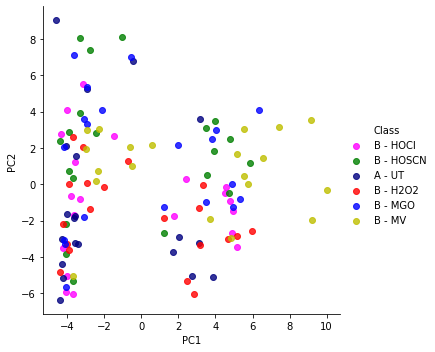

In [7]:
# sparse PCA
# use for cases when number of samples(e.g. patient) n << number of features(m/z) m

from sklearn.decomposition import SparsePCA
spca=SparsePCA(n_components=3,random_state=0)
sX_2D = spca.fit(Data_log).transform(Data_log)
sloadings = pd.DataFrame(spca.components_.T, columns=['PC1', 'PC2','PC3'])
sPCA_data=tmp_train
sPCA_data['PC1'] = sX_2D[:,0]
sPCA_data['PC2'] = sX_2D[:,1]
sPCA_data['PC3'] = sX_2D[:,2]
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
group_label = list(sPCA_data.columns)
sns.lmplot("PC1", "PC2", hue=group_label[1], data=sPCA_data, palette=colors, fit_reg=False)

C:\Users\rmb4918\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


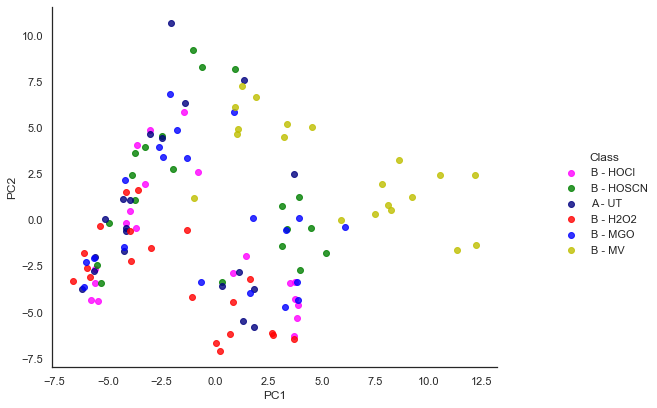

In [8]:
# PCA
sns.set_context("notebook")
sns.set_style("white")
from sklearn.decomposition import PCA
pca = PCA(n_components=3) #keep first 3 components
X_2D = pca.fit(Data_log).transform(Data_log)
loadings = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2','PC3'])

# label,y= np.unique(file['Label'],return_inverse = True)
# label=file['Label']
colors = ['green','red']
colors=['magenta','green','navy', 'r', 'b', 'y', 'orange', 'indigo']
# lw = 1

PCA_data=tmp_train.copy()
PCA_data['PC1'] = X_2D[:,0]
PCA_data['PC2'] = X_2D[:,1]
PCA_data['PC3'] = X_2D[:,2]


sns.lmplot("PC1", "PC2", hue='Class', data=PCA_data, palette=colors,fit_reg=False)
fig = plt.gcf()
fig.set_size_inches(10,6)

#save it
# plt.savefig('D:/BOX/Box Sync/RA/data/IMAGING/LD_REIMS/from Vince/cambridge multiple sclerosis/for Luca/PCA_pos.eps', format='eps')

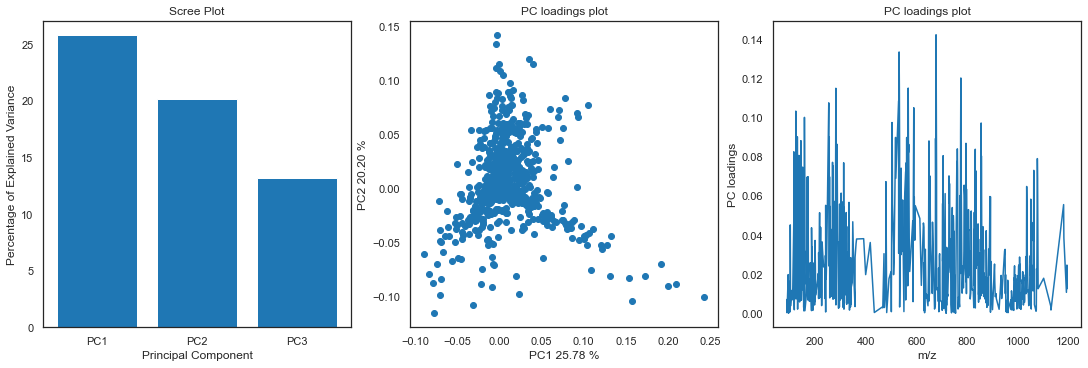

In [9]:
per_var = np.round(pca.explained_variance_ratio_* 100, decimals=1)
labels = ['PC' + str(x) for x in range(1, len(per_var)+1)]

fig,axs = plt.subplots(ncols=3,constrained_layout=True,figsize=(15,5))

axs[0].bar(x=range(1,len(per_var)+1), height=per_var, tick_label=labels)
axs[0].set_ylabel('Percentage of Explained Variance')
axs[0].set_xlabel('Principal Component')
axs[0].set_title('Scree Plot')

axs[1].scatter(loadings['PC1'],loadings['PC2'])
axs[1].set_title('PC loadings plot')
axs[1].set_xlabel('PC1 %0.2f %%' % (pca.explained_variance_ratio_[0] * 100))
axs[1].set_ylabel('PC2 %0.2f %%' % (pca.explained_variance_ratio_[1] * 100))

axs[2].plot(mz,loadings['PC2'].abs())
# axs[2].plot(mz,loadings['PC3'])
axs[2].set_title('PC loadings plot')
axs[2].set_xlabel('m/z')
axs[2].set_ylabel('PC loadings');


## 3D PCA (need to install plotly for this to work!)

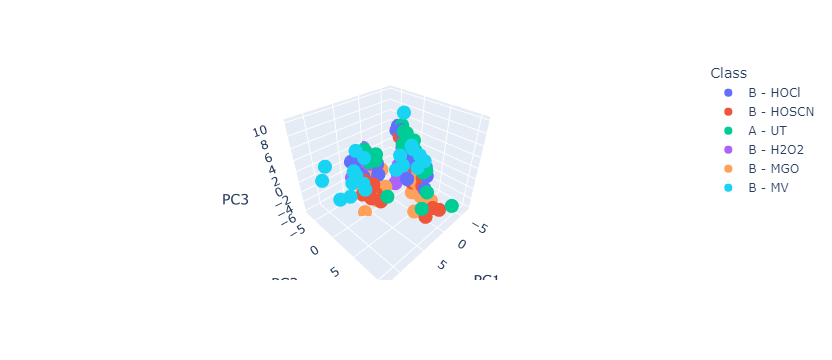

In [10]:
import plotly.express as px

fig = px.scatter_3d(PCA_data, x='PC1', y='PC2', z='PC3',
              color='Class')
fig.show()
#ax.scatter3D(xdata, ydata, zdata, c=file['Label'], label=file['Label']);
#fig = plt.gcf()
#fig.set_size_inches(12,6)

## *Feature selection using PCA (only if you have clear linear separation within a component)

In [11]:
# PC=loadings['PC3']
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project B/mz.txt', mz,delimiter=',')
# np.savetxt('D:/BOX//Box Sync/RA/data/IMAGING/DESI/CRUK/project b/pc.txt', PC,delimiter=',') #for me to save the components

# sorted_loading_values = PC.abs().sort_values(ascending=False)
# # sorted_loading_values
# top_30_mz = sorted_loading_values[0:100].index
# top_30_mz
# PCA_features=mz[top_30_mz]
# np.savetxt('D:/BOX/Box Sync/RA/data/IMAGING/DESI/CRUK/project E/features_PCA_APCvsKRAS.txt', PCA_features,delimiter=',')

# Classification models

In [12]:
# get group sizes to be used for cost sensitivity if biased
column = tmp_train['Class']

labelnames = set(column)
labelnames = list(labelnames)

w = np.zeros(len(labelnames))
for i in range(0,len(labelnames)):
    group=tmp_train[column== labelnames[i]]
#     group=file_resample[column== labelnames[i]]
    w[i]=(len(group))
    print('group' + str(i) + ' sampe size: '+str(w[i])+'\n')

print('ratio: '+str(w/max(w)))
weights = {labelnames[0]:1.0, labelnames[1]:w[0]/w[1]}

labelnames

group0 sampe size: 20.0

group1 sampe size: 20.0

group2 sampe size: 20.0

group3 sampe size: 20.0

group4 sampe size: 20.0

group5 sampe size: 20.0

ratio: [1. 1. 1. 1. 1. 1.]


['B - H2O2', 'B - MV', 'B - HOSCN', 'B - MGO', 'B - HOCl', 'A - UT']

## Train models with CV
## you can select the classifier ('method'), the cross-validation strategy ('cvsplit', ATM only LOGO or stratified K-fold) and implement a cost-sensitive approach (input 'weights')

## method available = 'LR'(Logistic Regression), 'LDA'(Liner Discriminant Analysis), 'KNN'(k-Nearest Neighbours), 'CART'(Decision Trees), 'NB'(Naiive Bayesian), 'SVM'(Support Vector Machine), 'RF'(Random Forest)

## CV strategies available = 'loo' (leave-one-group-out as specified by 'group' argument), 'kfold' (stratified, default k=10)

In [13]:
results = train_cv (Data_log, method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=tmp_train['Class'], weights = weights)

Method SVC(class_weight={'B - H2O2': 1.0, 'B - MV': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True) iteration 0 
that took 0.24718952178955078 seconds


## *Visualise CV splitting behaviour (for k-fold mostly)

<AxesSubplot:title={'center':'StratifiedKFold'}, xlabel='Sample index', ylabel='CV iteration'>

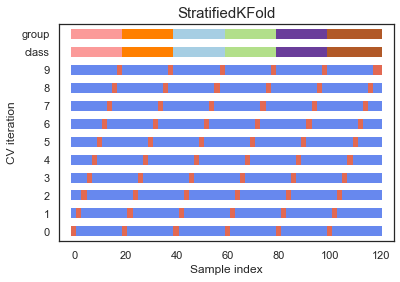

In [14]:
sns.set_context("notebook")
cvsplit = StratifiedKFold(n_splits=10)
old_label = tmp_train['Class'].copy()
old_group = tmp_train['Class'].copy()
plot_cv(cvsplit, Data_log, old_label, old_group, 10, lw=10)

## Model(s) evaluation - confusion matrix & ROC analysis

## if you want CM in sample numbers then just take away the 'normalize = true' during calculation

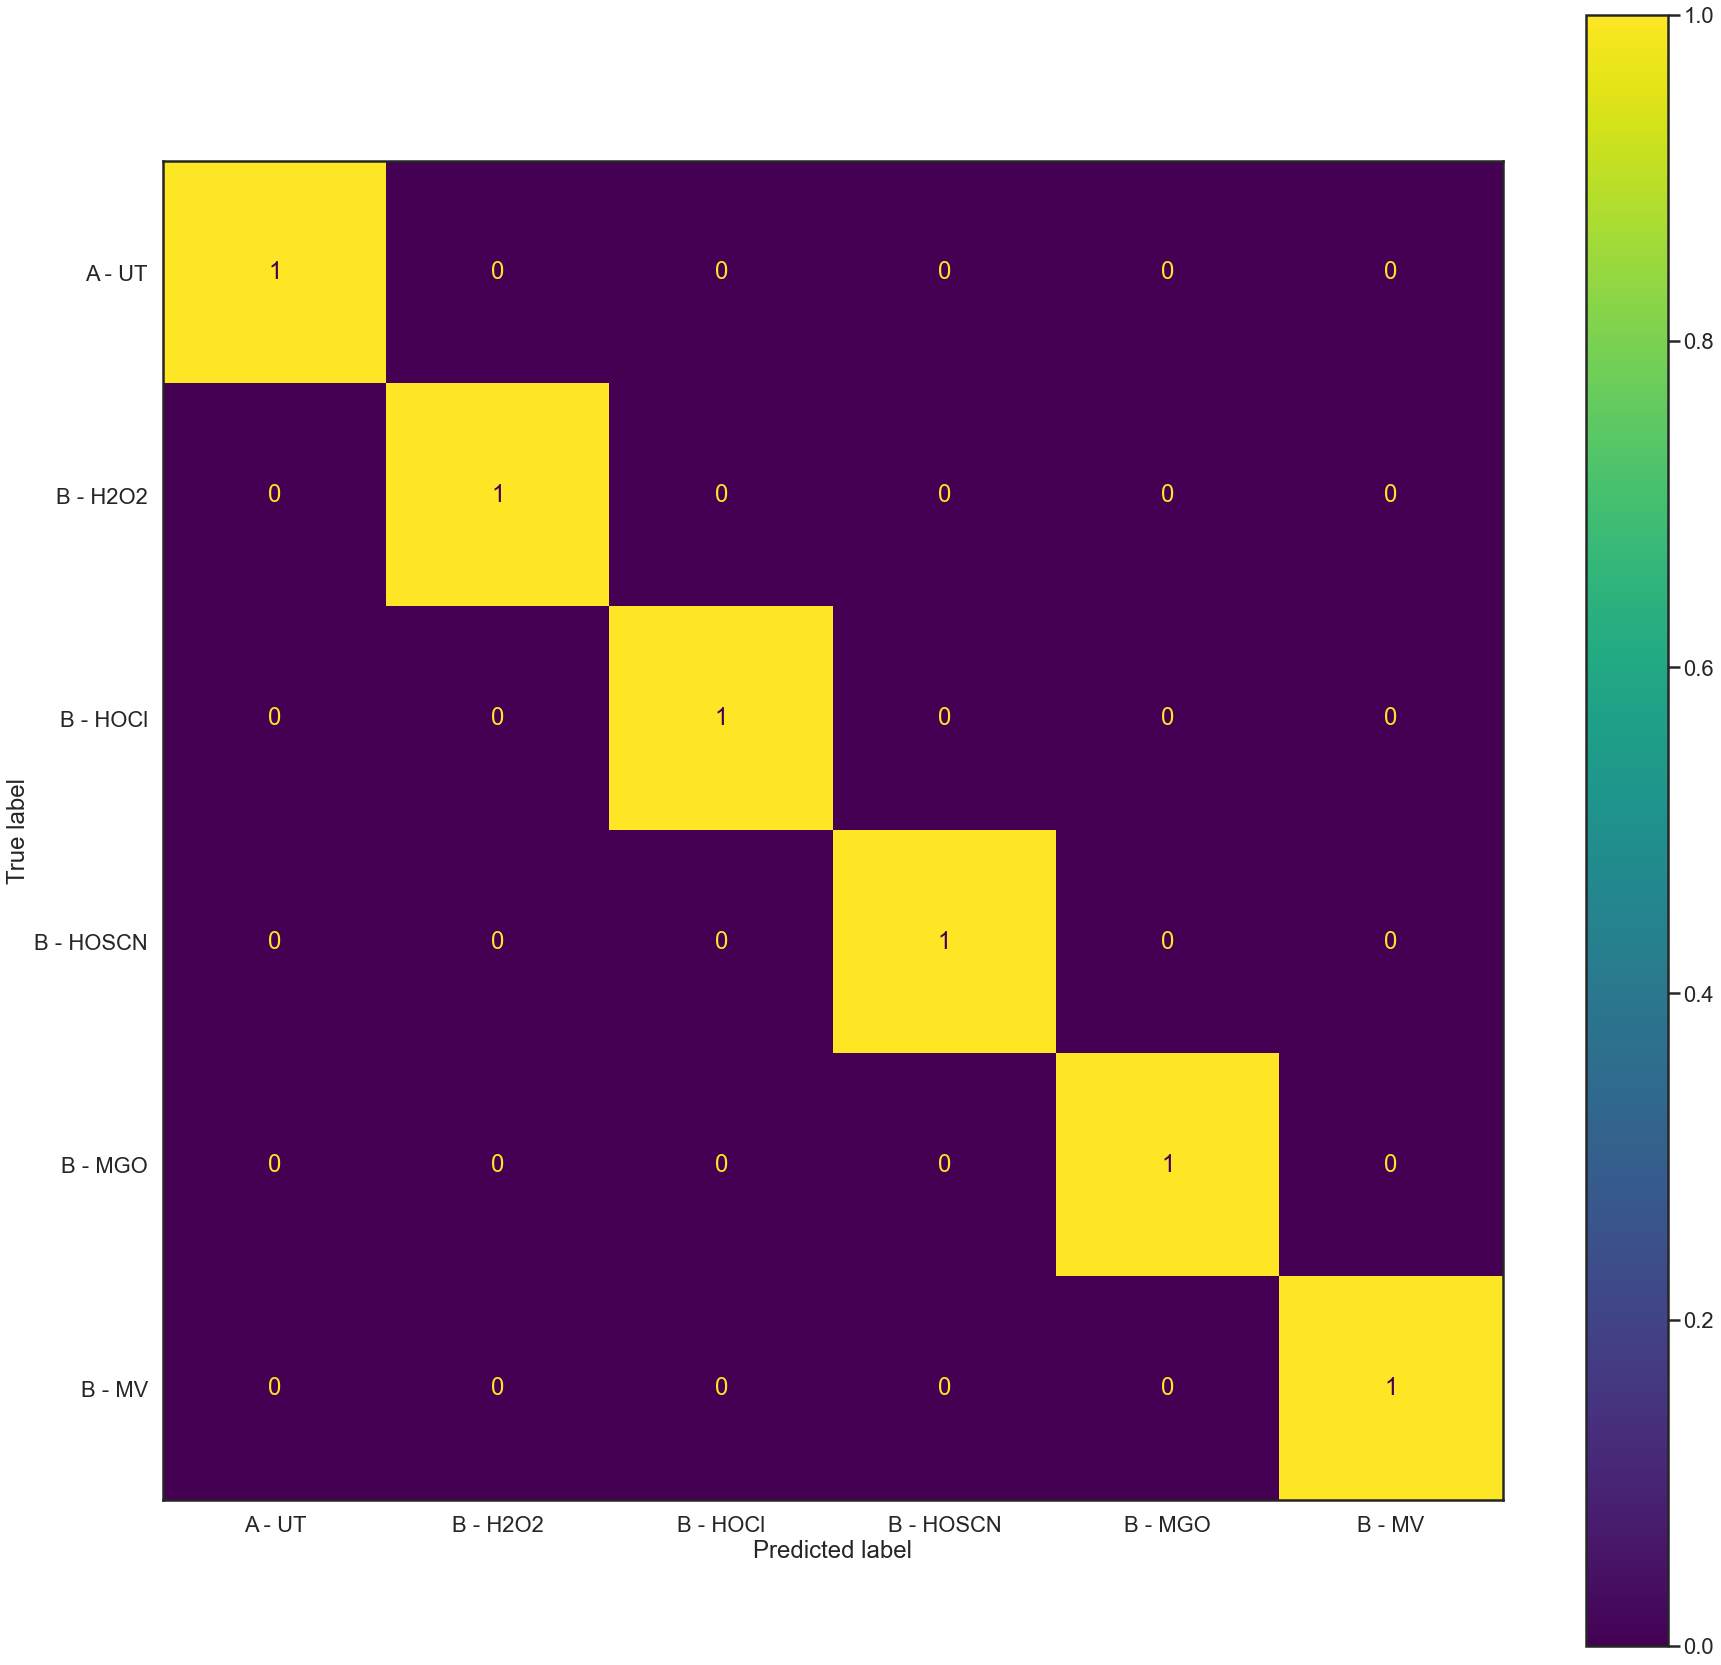

In [15]:
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
sns.set_context("poster")
classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

In [16]:
performance = calculate_FPASS (CM,cm_label)
performance

,class,accuracy,sensitivity,specificity,precision,F1
0,A - UT,1.0,1.0,1.0,1.0,1.0
1,B - H2O2,1.0,1.0,1.0,1.0,1.0
2,B - HOCl,1.0,1.0,1.0,1.0,1.0
3,B - HOSCN,1.0,1.0,1.0,1.0,1.0
4,B - MGO,1.0,1.0,1.0,1.0,1.0
5,B - MV,1.0,1.0,1.0,1.0,1.0
6,Average,1.0,1.0,1.0,1.0,1.0


## ROC analysis - this will plot the 'macro average' if you have more than 2 classes, you can plot for a particular class by e.g. defining the input argument 'plotwhich=2' (so plot ROC for class 2); and in the case of k-fold, it currently plots a randomly selected 'fold' (i.e. the performance may change everytime you plot); you can also save the predicted probabilities by defining 'saveprobs=True'
## to-do: plot the average of k-fold

there are 6 classes


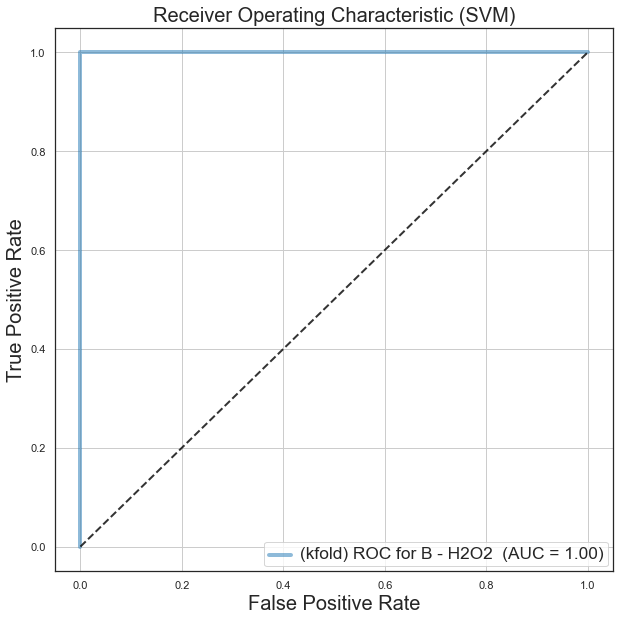

In [17]:
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import roc_auc_score
from random import randrange

[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_log, tmp_train['Class'], method='SVM', 
                                        cvsplit='kfold', plotwhich = 1, saveprobs = True)

# Save trained model & test new data

## the trained model will be saved to a folder called 'Trained_models', you can name the model to be anything (e.g. 'XXX.sav')

In [18]:
model_tosave = model
model_tosave.fit(Data_log, column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_test1.sav', 'wb'))

SVC(class_weight={'B - H2O2': 1.0, 'B - MV': 1.0},
    decision_function_shape='ovo', kernel='linear', probability=True)
saved


In [19]:
# load test data from file

tmp_test, Data_test, mz_test = load_data("test_set.csv", features = mz)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

data already has the same spectral variables


(24, 736)

C:\Users\rmb4918\Anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning:

X has feature names, but SVC was fitted without feature names



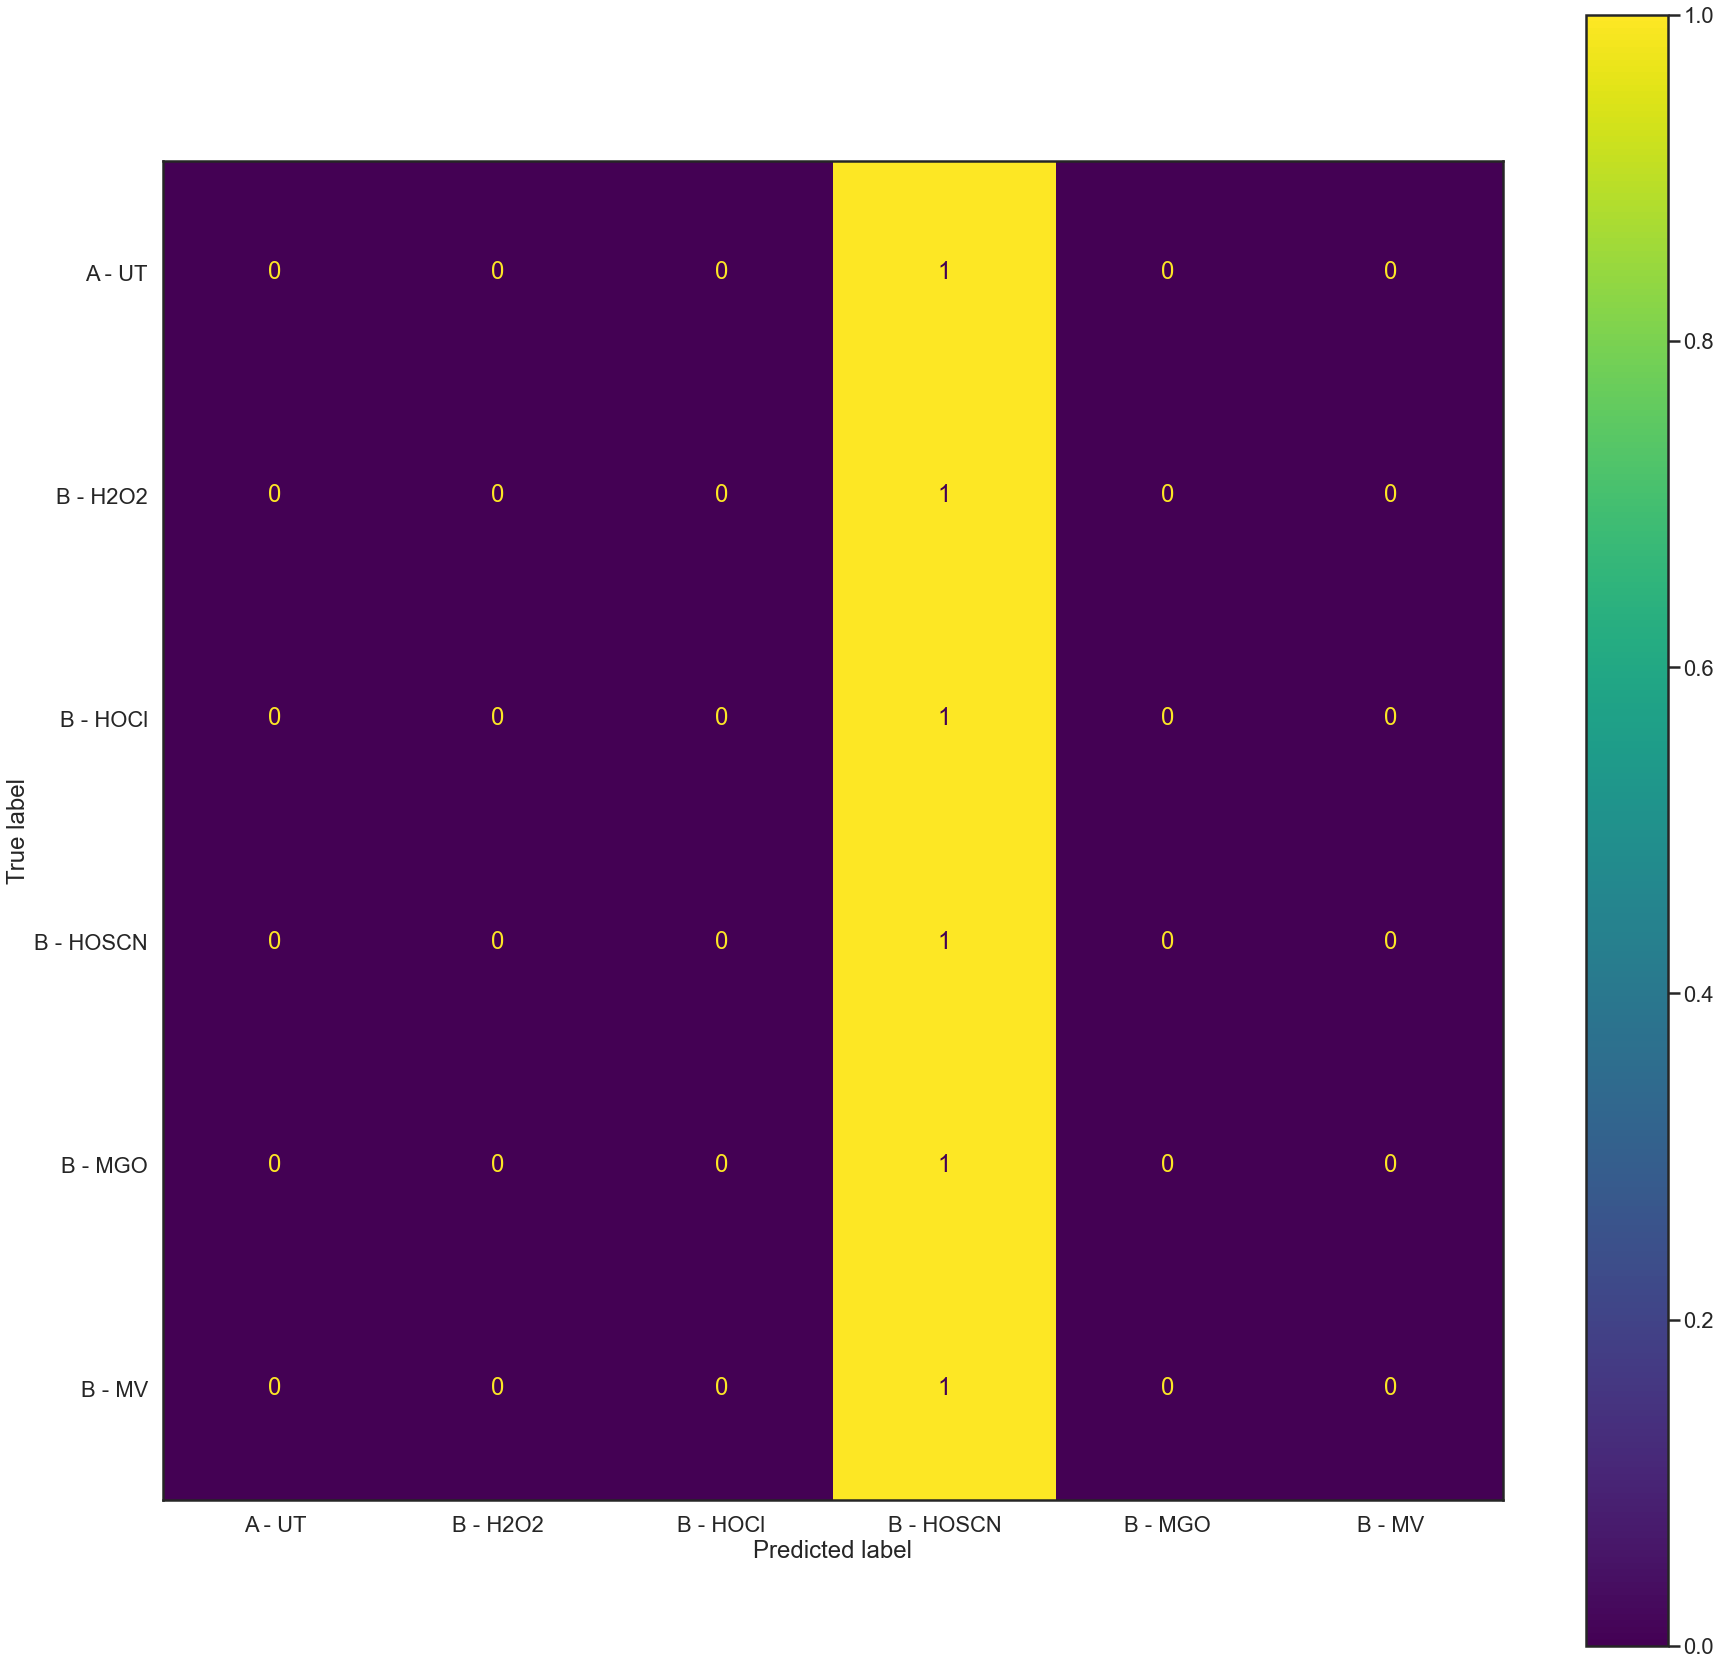

In [20]:
model_name = 'Trained_models/SVM_test1.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Class'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

## the CM alone can be 'deceiving' as most trained models are probabilistic and give the probabilities of a sample belonging to a certain class. If an inappropriate threshold was chosen (i.e. P>=threshold to be predicted to be a certain class), then the performance may appear to worsen when compared to CV results. To understand where this threshold should be, also check the ROC curves for the test data

there are 6 classes


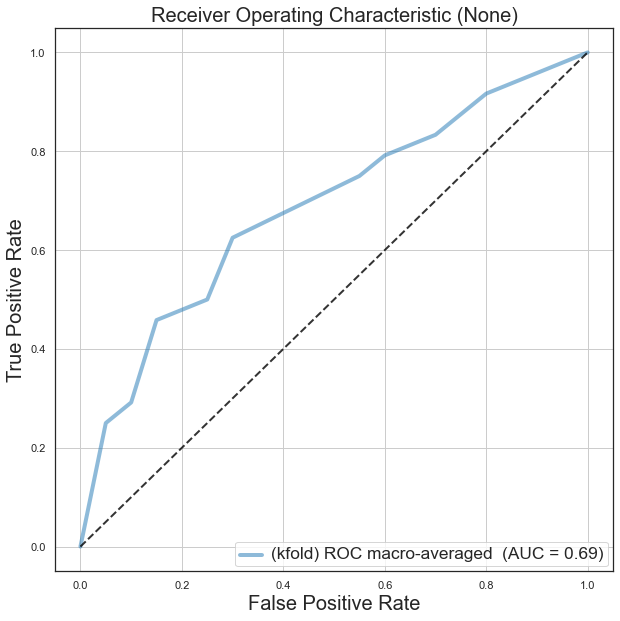

In [21]:
[model, all_probs, FPRs, TPRs, AUCs] = do_ROC (Data_test_log.values, tmp_test['Class'].values, saved_model = loaded_model,
        plotwhich = 'macro', saveprobs = True)

# Feature selection methods

## Feature selection with LR - there are 3 main methods:

## 1. Using the relative importance of LR coefficients obtained during model training; if you have more than 2 classes, then remember that LR CANNOT do true multi-class classification and instead it will do 'one-vs-rest' for as many times as you have classes. The output features are automatically saved (unless you turn it off with 'save = False') and you can define the number features (e.g. num_features = 50)

In [24]:
LR_features, importance = LR_importance(Data_log, tmp_train['Class'], num_features = 30, save=False)
LR_features

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,761.5322,469.6399,759.5178,531.3519,629.4887,242.1511,762.5346,262.1424,829.5888,908.5853,559.3824,313.2331,532.3553,630.4931,324.2301
1,627.4796,760.5198,631.4914,295.2610,677.4105,529.3365,518.3352,719.4972,705.4458,477.1705,499.6417,274.0893,533.3578,529.6404,332.1740
2,320.1389,775.5368,268.1668,324.2301,298.2139,296.1976,242.1511,829.5888,258.1462,284.1617,294.1232,270.1825,761.5322,269.1707,211.0923
3,297.2024,259.1490,830.5896,477.1705,299.2176,762.5346,151.0222,719.4972,318.2042,243.1554,1016.7027,323.0427,272.1626,260.1527,306.1573
4,719.4972,721.5010,688.4914,775.5368,720.4921,689.4949,722.5045,690.5064,693.4749,761.5322,691.5098,762.5346,730.5372,687.4805,829.5888
5,151.0222,723.5078,714.7243,772.4698,662.4762,686.4758,745.7244,731.5392,139.0040,707.4807,692.5128,311.1709,774.4924,744.5524,714.5075
6,774.4924,761.5322,829.5888,762.5346,775.5368,759.5178,313.2331,719.4972,795.5501,295.2610,531.3519,760.5198,274.0893,721.5010,559.3824
7,720.4921,517.3321,532.3553,688.4914,728.5233,355.1056,856.6547,730.5372,560.3867,787.5509,745.5025,690.5064,772.4698,691.5098,558.3718
8,759.5178,728.5233,760.5198,761.5322,729.5257,762.5346,747.6335,730.5372,731.5392,795.6264,747.8322,747.7379,763.5313,324.2301,796.6302
9,295.2610,855.6511,748.0099,748.7435,267.2297,318.2042,700.4915,831.6026,795.5501,274.1410,130.0882,856.6547,719.4972,787.5509,794.6198


## *Feature selection for LR using log-likelihood test, only for binary classification!

In [39]:
from sklearn.metrics import log_loss
from scipy.stats import chi2

LR_features2 = LR_loglike(Data_log, tmp_train_r['Class'], threshold = 2.0, save = False)
LR_features2

array([  50.16054535,   52.30213547,   61.0007515 , ..., 1498.84692383,
       1499.19555664, 1500.20202637])

## Feature selection using RFE (Recursive Feature Elimination)
## standard RFE produces any defined number of features

In [25]:
# Here I chose 30 features

from sklearn.feature_selection import RFE
print(model)

RFE_features = RFE_select(Data_log, tmp_train['Class'],n_features = 20)
RFE_features

SVC(class_weight={'B - MGO': 1.0, 'B - MV': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 13.770913124084473 seconds


,0
0,242.1511
1,262.1424
2,284.1617
3,295.2610
4,298.2139
5,309.1634
6,313.2331
7,320.1389
8,324.2301
9,509.2870


## if you are unsure how many features are necessary, use RFECV below as it will use a CV-based 'grid search' to also determine the optimal numer of features (5-fold by default), this is much slower!

In [ ]:
# RFECV - use CV to determine & select best number of features

from sklearn.feature_selection import RFECV
print(model)

RFECV_features = RFECV_select(Data_log, tmp_train['Class'])
RFECV_features

SVC(class_weight={'B - MGO': 1.0, 'B - MV': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True)

that took 71.8437819480896 seconds


,0
0,242.1511
1,262.1424
2,284.1617
3,295.2610
4,320.1389
5,324.2301
6,509.2870
7,629.4887
8,653.5349
9,719.4972


## Feature selection with LASSO (only for binary classification!)

In [32]:
from sklearn.preprocessing import label_binarize
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV

lasso_features = LASSO_select(Data_log,tmp_train_r['Class'])
lasso_features

NameError: name 'tmp_train_r' is not defined

## Combine different FS approaches to generate a list of (overlapping) features & generate new data matrix with only these features

In [34]:
allfeatures = match_features([RFE_features])
allfeatures

Data_train_s=np.zeros((len(Data_train),len(allfeatures)))
for n in range (0,len(allfeatures)):
    index= np.argmin(abs(mz-allfeatures[n]))
    Data_train_s[:,n]=Data_train.iloc[:,index]
    
output = pd.DataFrame(data=Data_train_s)
output['Class'] = tmp_train['Class']
output['Sample'] = tmp_train['Sample']
i = 0
for mz_i in allfeatures:
    mz_i = float(mz_i)
    output = output.rename(columns={i: (mz_i)})
    i = i+1
output

,242.1511,262.1424,284.1617,295.261,298.2139,309.1634,313.2331,320.1389,324.2301,509.287,...,653.5349,719.4972,721.501,722.5045,759.5178,761.5322,762.5346,796.6302,Class,Sample
0,6946.783258,0.000000,35466.062310,0.000000,6861.946316,0.000000,0.000000,36841.107440,0.0,0.000000,...,27513.116030,135143.410100,143205.74680,49135.356870,28966.39272,57960.93961,22153.64708,74491.761970,B - HOCl,1
1,5763.205898,0.000000,33705.141840,0.000000,7078.235623,0.000000,0.000000,34699.150910,0.0,8315.590198,...,16147.212840,278838.289800,222115.90280,77370.700640,47634.22849,95093.56575,35531.59813,40403.205180,B - HOCl,2
2,3663.118255,0.000000,24782.960080,6275.816987,4758.349327,0.000000,0.000000,27050.753630,0.0,4481.885874,...,22178.723510,154439.582000,148256.37000,49678.375500,40268.17444,73807.34507,27656.15337,111625.761700,B - HOCl,3
3,3160.429796,0.000000,13483.962530,7162.258998,0.000000,0.000000,2914.354522,15030.449380,0.0,4549.027807,...,10581.088910,149247.095200,115620.34290,37972.872170,31322.76191,56005.09852,21367.59740,86625.912210,B - HOCl,4
4,1788.750834,0.000000,8983.958435,8700.435187,0.000000,0.000000,1985.729028,8478.885402,0.0,2022.911991,...,6225.005906,81210.520100,70908.63505,25705.423040,18853.78284,34028.02890,13298.82968,37858.756580,B - HOCl,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,16735.927650,0.000000,10479.473160,7901.788702,3244.003839,0.000000,1813.949666,0.000000,0.0,0.000000,...,4556.157995,12950.634710,22907.45841,8738.700207,105603.77670,121772.69360,43400.52747,3781.586681,B - MV,116
116,34409.889460,0.000000,14148.063540,20688.891080,7722.437081,0.000000,0.000000,0.000000,0.0,0.000000,...,11367.941510,19648.915130,46040.01342,17051.127820,220468.78170,256698.61640,94685.91717,10771.357250,B - MV,117
117,28217.345880,2907.424803,19090.929640,10012.342770,6441.159303,1742.032091,0.000000,0.000000,0.0,0.000000,...,5715.683771,15055.535400,37982.17548,14781.179540,146240.52720,169796.57130,60043.04690,4551.231647,B - MV,118
118,5339.156651,0.000000,7484.938995,6462.387172,1947.075776,609.254180,816.685504,0.000000,0.0,0.000000,...,1857.783558,4474.869813,14970.79660,5562.855774,42418.39993,64966.58182,24199.08789,1288.201785,B - MV,119


## Save new data matrix

In [35]:
output.to_csv (r'data_select_test.csv', index = False, header=True)
output

,242.1511,262.1424,284.1617,295.261,298.2139,309.1634,313.2331,320.1389,324.2301,509.287,...,653.5349,719.4972,721.501,722.5045,759.5178,761.5322,762.5346,796.6302,Class,Sample
0,6946.783258,0.000000,35466.062310,0.000000,6861.946316,0.000000,0.000000,36841.107440,0.0,0.000000,...,27513.116030,135143.410100,143205.74680,49135.356870,28966.39272,57960.93961,22153.64708,74491.761970,B - HOCl,1
1,5763.205898,0.000000,33705.141840,0.000000,7078.235623,0.000000,0.000000,34699.150910,0.0,8315.590198,...,16147.212840,278838.289800,222115.90280,77370.700640,47634.22849,95093.56575,35531.59813,40403.205180,B - HOCl,2
2,3663.118255,0.000000,24782.960080,6275.816987,4758.349327,0.000000,0.000000,27050.753630,0.0,4481.885874,...,22178.723510,154439.582000,148256.37000,49678.375500,40268.17444,73807.34507,27656.15337,111625.761700,B - HOCl,3
3,3160.429796,0.000000,13483.962530,7162.258998,0.000000,0.000000,2914.354522,15030.449380,0.0,4549.027807,...,10581.088910,149247.095200,115620.34290,37972.872170,31322.76191,56005.09852,21367.59740,86625.912210,B - HOCl,4
4,1788.750834,0.000000,8983.958435,8700.435187,0.000000,0.000000,1985.729028,8478.885402,0.0,2022.911991,...,6225.005906,81210.520100,70908.63505,25705.423040,18853.78284,34028.02890,13298.82968,37858.756580,B - HOCl,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,16735.927650,0.000000,10479.473160,7901.788702,3244.003839,0.000000,1813.949666,0.000000,0.0,0.000000,...,4556.157995,12950.634710,22907.45841,8738.700207,105603.77670,121772.69360,43400.52747,3781.586681,B - MV,116
116,34409.889460,0.000000,14148.063540,20688.891080,7722.437081,0.000000,0.000000,0.000000,0.0,0.000000,...,11367.941510,19648.915130,46040.01342,17051.127820,220468.78170,256698.61640,94685.91717,10771.357250,B - MV,117
117,28217.345880,2907.424803,19090.929640,10012.342770,6441.159303,1742.032091,0.000000,0.000000,0.0,0.000000,...,5715.683771,15055.535400,37982.17548,14781.179540,146240.52720,169796.57130,60043.04690,4551.231647,B - MV,118
118,5339.156651,0.000000,7484.938995,6462.387172,1947.075776,609.254180,816.685504,0.000000,0.0,0.000000,...,1857.783558,4474.869813,14970.79660,5562.855774,42418.39993,64966.58182,24199.08789,1288.201785,B - MV,119


## Train & evaluate new model with only selected features

In [36]:
results = train_cv (data_norm(Data_train_s, method='log'), method='SVM', cvsplit='kfold', 
                    label=column.tolist(), group=output['Class'], weights = weights)

Method SVC(class_weight={'B - MGO': 1.0, 'B - MV': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True) iteration 0 
that took 0.10674476623535156 seconds


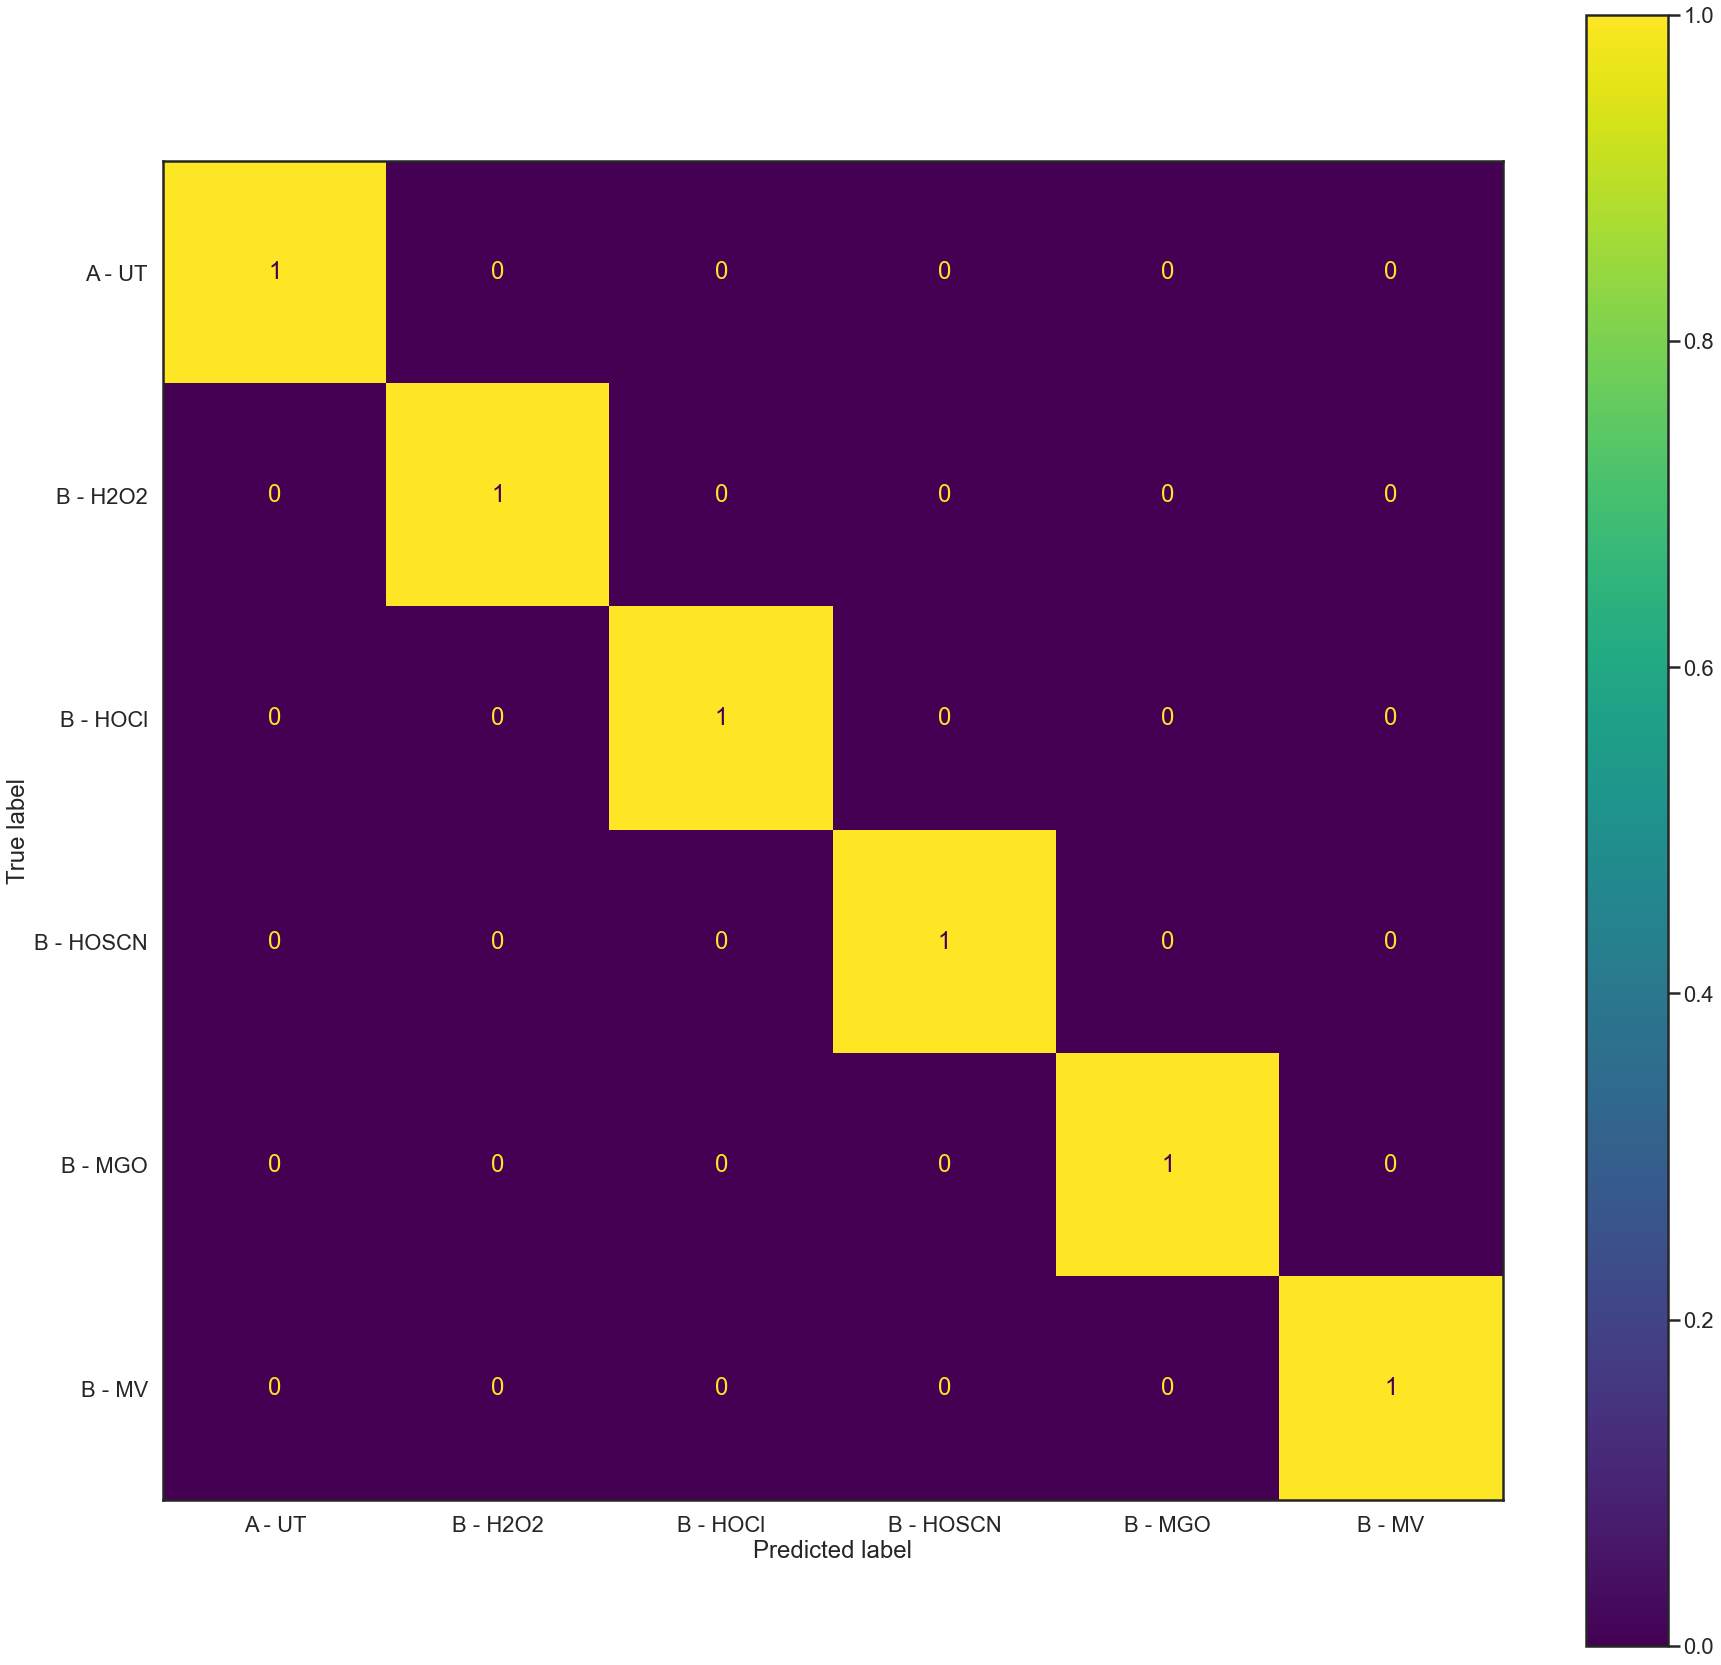

In [37]:
sns.set_context("poster")

classes = column

cm_label = np.unique(classes)
CM = confusion_matrix(classes, results, normalize='true')

disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

## Save new model with only selected features

In [38]:
model_tosave = model
model_tosave.fit(data_norm(Data_train_s, method='log'), column.tolist())

print(model)
print('saved')

if os.path.isdir('Trained_models') == False:
    path = os.path.join(cwd, 'Trained_models')
    os.mkdir(path)

pickle.dump(model_tosave, open('Trained_models/SVM_test_2.sav', 'wb'))

SVC(class_weight={'B - MGO': 1.0, 'B - MV': 1.0}, decision_function_shape='ovo',
    kernel='linear', probability=True)
saved


## Load data and test with new model

In [39]:
tmp_test, Data_test,mz_test = load_data("test_set.csv", features = allfeatures)
# Data_test_n = data_norm(Data_test, method='tic')
Data_test_log = data_norm(Data_test, method='log')
Data_test_log.shape

data already has the same spectral variables


(24, 736)

In [40]:
model_name = 'Trained_models/SVM_test_2.sav'
loaded_model = pickle.load(open(model_name, 'rb'))
classes = tmp_test['Class'].tolist()
test_results = loaded_model.predict(Data_test_log)
CM = confusion_matrix(classes, test_results, normalize='true')

sns.set_context("poster")
disp = ConfusionMatrixDisplay(confusion_matrix=CM, display_labels=cm_label)
disp.plot()
fig = plt.gcf()
fig.set_size_inches(30,30)

C:\Users\rmb4918\Anaconda3\lib\site-packages\sklearn\base.py:443: UserWarning:

X has feature names, but SVC was fitted without feature names



ValueError: X has 736 features, but SVC is expecting 20 features as input.

# Feature selection with univariate analysis

## Kruskal-Wallis test (non-parametric for multiple groups)

In [41]:
from bioinfokit import analys, visuz
from scipy import stats

green = labelnames[0]
red = labelnames[1]
green_data=Data_log[tmp_train['Class']== green]
green_data = pd.DataFrame(green_data)
red_data=Data_log[tmp_train['Class']== red]
red_data = pd.DataFrame(red_data)
print('comparing '+ green+' & '+red)

p_vals_KW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_KW[i]=1
    else:
        dum1=stats.kruskal(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_KW[i]=(dum2)        

comparing B - MGO & B - MV


## *Mann-Whitney test (non-parametric binary problem)

## KW test = MW test for a two-way comparison~

In [42]:
p_vals_MW=np.zeros(len(mz))
for i in range(len(mz)):
#     print(i)
    if (np.round(np.mean(green_data.iloc[:,i]),4))== (np.round(np.mean(red_data.iloc[:,i]),4)):
        p_vals_MW[i]=1
    else:
        dum1=stats.mannwhitneyu(green_data.iloc[:,i],red_data.iloc[:,i])
        dum2=dum1.pvalue
        p_vals_MW[i]=(dum2)

## FDR correction

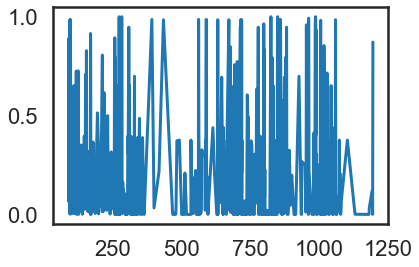

In [43]:
[rejected,correct_p]=statsmodels.stats.multitest.fdrcorrection(p_vals_KW, alpha=0.05, method='indep', is_sorted=False)

plt.plot(mz,correct_p)
# p_vals.shape

## *features can be selected based on corrected p-values alone or using volcano plot (below)

In [44]:
p_threshold = 0.05
features = [correct_p <= p_threshold]
features_KW = mz[tuple(features)]
features_KW

array([  93.0316,   94.5612,   94.7814,   95.7893,   97.0286,   99.0424,
         99.9237,  101.0189,  108.0233,  109.0271,  117.0166,  117.0535,
        121.0264,  124.0142,  125.0241,  127.0422,  128.0325,  130.0882,
        135.0443,  137.0243,  138.017 ,  139.004 ,  145.0494,  146.0423,
        148.0371,  155.0333,  156.9951,  159.0664,  165.0237,  166.0151,
        167.0177,  167.0588,  169.1198,  170.0572,  171.0991,  173.0819,
        175.0238,  179.0704,  183.0017,  185.0478,  185.1509,  187.1297,
        197.1518,  199.0063,  199.1666,  201.0248,  205.1587,  212.0717,
        213.1477,  213.1822,  215.1614,  219.0461,  227.1978,  228.2025,
        233.1528,  239.0591,  239.2009,  241.053 ,  241.1178,  241.2137,
        242.1511,  242.2185,  245.0391,  256.1299,  257.0148,  257.1378,
        258.1462,  259.149 ,  260.1527,  263.0682,  266.8009,  267.2297,
        269.2448,  270.2496,  270.7938,  274.0893,  274.141 ,  275.0944,
        275.1437,  277.1191,  281.2451,  282.2485, 

## fold changes calculation for volcano plot

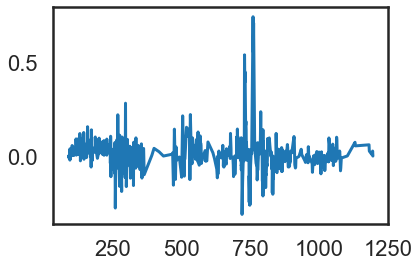

In [45]:
green_mean=np.mean(green_data.iloc[:,:])
green_mean=np.where(green_mean==0, 1, green_mean) 
red_mean=np.mean(red_data.iloc[:,:])
red_mean=np.where(red_mean==0, 1, red_mean) 

fc=green_mean/red_mean
log2fc=np.log2(fc)

plt.plot(mz,log2fc)

## plot and save volcano plot
## working example: https://www.reneshbedre.com/blog/volcano.html

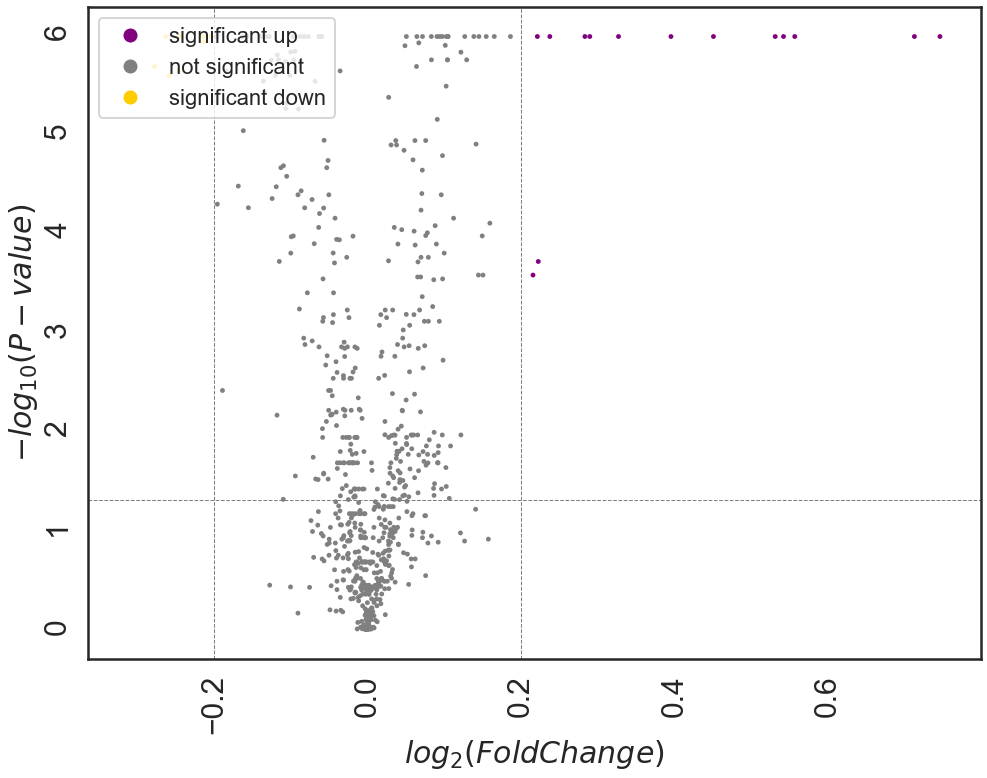

In [46]:
mzlabel=[''] * len(mz)
for i in range(len(mz)):
    mzlabel[i]=str(mz[i])

volcano_data=pd.DataFrame(index=range(0,len(mz)),columns=['pvals','fc','mz'])
volcano_data.iloc[:,0]=correct_p
volcano_data.iloc[:,1]=log2fc
volcano_data.iloc[:,2]=mzlabel
top30=volcano_data['pvals'].sort_values(ascending=True)
top30 = top30[0:30].index
# labels=mz[top30]
labels=np.array2string(mz[top30],separator=',',precision=12)

sns.set_context("poster")
fig = visuz.GeneExpression.volcano(df=volcano_data, lfc='fc', pv='pvals',geneid='mz', dim = [16,12],
                                   lfc_thr=(0.2, 0.2), pv_thr=(0.05, 0.05),
                             genenames=({
'152.9887':'metabolite1',
 '778.5634':'lipid1'
}),
color=("purple", "grey", "#FFCC00"), gstyle = 1, gfont = 12.0, plotlegend=True,legendpos='upper left',
                                   axtickfontsize = 30,axlabelfontsize=30, sign_line=True,show=True)

## select features according volcano plot thresholds

In [47]:
p_threshold = 0.05
fc_threshold = 0.1
condition=(volcano_data['pvals'] <= p_threshold) & (abs(volcano_data['fc']) >= fc_threshold)
vol_features=pd.DataFrame(mz[condition])

vol_features
# vol_features.to_csv (r'vol_features.csv', index = False, header=True)

,0
0,185.1509
1,241.0530
2,242.1511
3,258.1462
4,259.1490
...,...
80,832.6065
81,833.6055
82,843.5380
83,908.5853


# Box plotting

## save box plots of selected features to defined path
## syntax: box_plot(list of features, mz, filename, column name to use for labels, save (True or False), savepath)

In [48]:
features_from_file = np.loadtxt('features_volcano.txt')

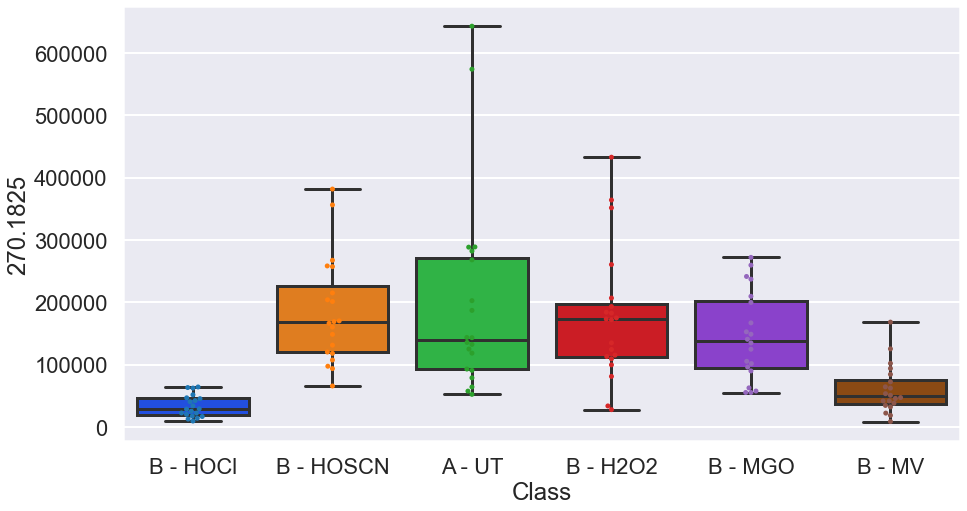

In [51]:
# box_plot([features_from_file], mz, tmp_train,'Label', save=False, savepath = 'E:/Data/Dani')
box_plot(['269'], mz, tmp_train,'Class', save=False, savepath = 'E:/Data/Dani')